In [1]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
import matplotlib.patches as patches
from matplotlib.patches import Circle
from matplotlib.path import Path
from scipy.optimize import curve_fit, least_squares, lsq_linear
from scipy.signal import convolve
from scipy.linalg import toeplitz
from scipy.ndimage import gaussian_filter1d
from IPython import get_ipython
from sklearn.isotonic import IsotonicRegression
import osqp
from scipy import sparse

#simulations
import pandas as pd
import seaborn as sns

In [2]:
# Load DICOM files

dicom_dir = "/Users/Ashley/Downloads/DICOM_Folder_018/DICOM" #"PATH_TO_DICOM_FOLDER"

files = [
    pydicom.dcmread(os.path.join(dicom_dir, f))
    for f in os.listdir(dicom_dir)
    if f.lower().endswith((".ima", ".dcm"))
]
print("Loaded:", len(files))


Loaded: 1023


In [3]:
# Sort files for myocardium data

# Selecting motion corrected and normalized files
perfusion_files = [f for f in files if "WIP810_perf_ 3sl TPAT3 PF7ov8 32chFB_MOCO_NORM" == getattr(f, "SeriesDescription", "")]

# Sort by InstanceNumber then SliceLocation
perfusion_files.sort(key=lambda f: (int(getattr(f, "InstanceNumber", 0)), f.SliceLocation))

# Detect unique slice locations in order
slice_positions_unique = sorted(list(set(f.SliceLocation for f in perfusion_files)))
n_slices = len(slice_positions_unique)
n_time = len(perfusion_files) // n_slices

print("Number of slices:", n_slices)
print("Number of time points:", n_time)

# Convert to array (time, slices, H, W)
images_array = np.zeros((n_time, n_slices, *perfusion_files[0].pixel_array.shape), dtype=perfusion_files[0].pixel_array.dtype)
for t in range(n_time):
    for s in range(n_slices):
        idx = t * n_slices + s
        images_array[t, s] = perfusion_files[idx].pixel_array

Number of slices: 3
Number of time points: 40


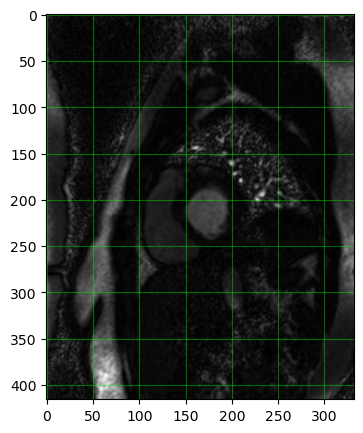

In [4]:
# Select slice (basal, mid, apical)
slice_index = 0 #0,1,2
images_slice_orig = images_array[:, slice_index, :, :]

# Show to determine cropping
plt.figure(figsize=(5, 5))
plt.imshow(images_slice_orig[15], cmap="gray")  #change "15" to display a different slice
plt.grid(True, color='lime', alpha=0.4)
plt.show()

Original shape: (40, 416, 332)
Cropped shape: (40, 120, 120)


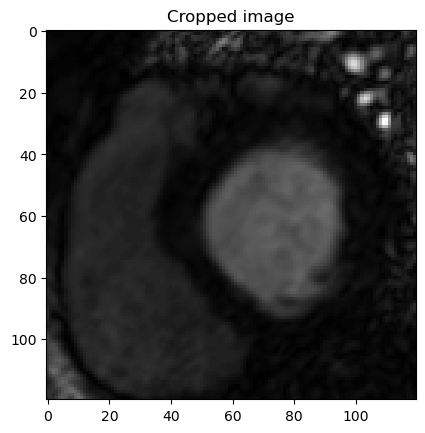

In [5]:
# Manually crop frames to focus on the heart
y_min, y_max = 150, 270   # adjust as needed
x_min, x_max = 100, 220   # adjust as needed

images_slice = images_slice_orig[:, y_min:y_max, x_min:x_max]

print("Original shape:", images_slice_orig.shape)
print("Cropped shape:", images_slice.shape)

# Show cropped image
plt.imshow(images_slice[15], cmap="gray")
plt.title("Cropped image")
plt.show()

In [6]:
# Sorting files for dilute AIF data

aif_files = [f for f in files if "WIP810_DILUTE_STRESS_perf_ 1sl TPAT3 PF7ov8 32chFB_MOCO_NORM" in getattr(f, "SeriesDescription", "")]

# Sort by InstanceNumber then SliceLocation
aif_files.sort(key=lambda f: (int(getattr(f, "InstanceNumber", 0)), f.SliceLocation))

# Detect unique slice locations in order
aif_slice_positions_unique = sorted(list(set(f.SliceLocation for f in aif_files)))
aif_n_slices = len(aif_slice_positions_unique)
aif_n_time = len(aif_files) // aif_n_slices

print("Number of slices:", aif_n_slices)
print("Number of time points:", aif_n_time)

# Convert to array (time, slice, height, width)
aif_images_array = np.zeros((aif_n_time, aif_n_slices, *aif_files[0].pixel_array.shape), dtype=aif_files[0].pixel_array.dtype)
for t in range(aif_n_time):
    for s in range(aif_n_slices):
        idx = t * aif_n_slices + s
        aif_images_array[t, s] = aif_files[idx].pixel_array
        

Number of slices: 3
Number of time points: 40


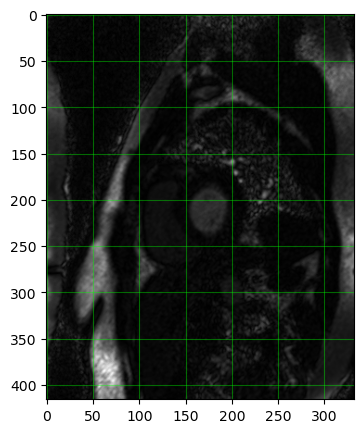

In [7]:
# Select slice
aif_images_slice = aif_images_array[:, slice_index, :, :]

# Show to determine cropping
plt.figure(figsize=(5, 5))
plt.imshow(aif_images_slice[15], cmap="gray")
plt.grid(True, color='lime', alpha=0.4)
plt.show()

Original shape: (40, 416, 332)
Cropped shape: (40, 150, 150)


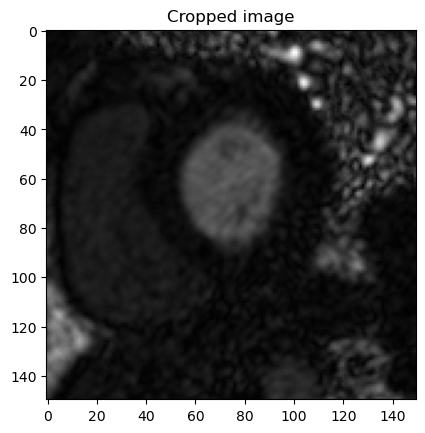

In [8]:
# Manually crop frames around heart for dilute scan
y_min, y_max = 150, 300   # adjust as needed
x_min, x_max = 100, 250   # adjust as needed

aif_images_cropped = aif_images_slice[:, y_min:y_max, x_min:x_max]

print("Original shape:", aif_images_slice.shape)
print("Cropped shape:", aif_images_cropped.shape)

# Use cropped version downstream
aif_images_slice = aif_images_cropped

plt.imshow(aif_images_slice[15], cmap="gray")
plt.title("Cropped image")
plt.show()

In [9]:
%matplotlib qt

ipython = get_ipython()
if ipython:
    ipython.run_line_magic("matplotlib", "qt")
    
# Select LV center to define ROI

plt.figure(figsize=(6, 6))
plt.imshow(images_slice[15], cmap="gray")
plt.title("Click the left ventricle center (window will close after clicking)")

# Wait for one click (returns [(x, y)])
pts = plt.ginput(1, timeout=0)
plt.pause(0.5)
plt.close()
    
if len(pts) > 0:
    x_lv_center, y_lv_center = pts[0]
    print(f"LV center selected at: x={x_lv_center:.1f}, y={y_lv_center:.1f}")

else:
    print("No point selected")


LV center selected at: x=72.1, y=64.7


In [11]:
# ROI selection for myocardium
    # Controls:
        # Left click: move circle center
        # Scroll: change radius
        # Up/Down arrows: fine radius adjustment
        # Close the window when finished

%matplotlib qt

frame_index = 15
img = images_slice[frame_index]

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img, cmap='gray')
ax.set_title("Move and resize the circle to fit the myocardium.\n"
             "Click to move center | Scroll or use up/down arrows to change radius\n"
             "Close window when done.")
circle = Circle((img.shape[1]//2, img.shape[0]//2), radius=60, alpha=0.5, edgecolor='lime', facecolor='none', lw=4)
ax.add_patch(circle)

state = {'radius': 60}

def on_scroll(event):
    if event.button == 'up':
        state['radius'] += 5
    elif event.button == 'down' and state['radius'] > 5:
        state['radius'] -= 5
    circle.set_radius(state['radius'])
    fig.canvas.draw_idle()

def on_press(event):
    if event.button == 1:  # left click to move
        circle.center = (event.xdata, event.ydata)
        fig.canvas.draw_idle()
        
def on_key(event):
    # Use arrow keys to change radius
    if event.key == 'up':
        state['radius'] += 1
    elif event.key == 'down' and state['radius'] > 1:
        state['radius'] -= 1
    circle.radius = state['radius']
    fig.canvas.draw_idle()

cid_scroll = fig.canvas.mpl_connect('scroll_event', on_scroll)
cid_click = fig.canvas.mpl_connect('button_press_event', on_press)
fig.canvas.mpl_connect('key_press_event', on_key)

plt.show()

In [12]:
# Run after myocardium selection window is closed
x_myo_center, y_myo_center = circle.center
myo_radius = state['radius']
print(f"Selected circle center for myocardium: ({x_myo_center:.1f}, {y_myo_center:.1f}), radius = {myo_radius:.1f}")


Selected circle center for myocardium: (74.4, 63.4), radius = 29.0


In [13]:
# Select LV center for dilute scan
%matplotlib qt

# Select LV center for dilute AIF
frame_idx = 15
plt.figure(figsize=(6, 6))
plt.imshow(aif_images_slice[frame_idx], cmap="gray")
plt.title("Click the dilute lv center (window will close after clicking)")

# Wait for user click
pts = plt.ginput(1, timeout=0)
plt.pause(0.5)
plt.close()

if len(pts) > 0:
    x_dil_lv_center, y_dil_lv_center = pts[0]
    print(f"Dilute LV center selected at: x={x_dil_lv_center:.1f}, y={y_dil_lv_center:.1f}")
else:
    print("No point selected")

Dilute LV center selected at: x=73.4, y=62.2


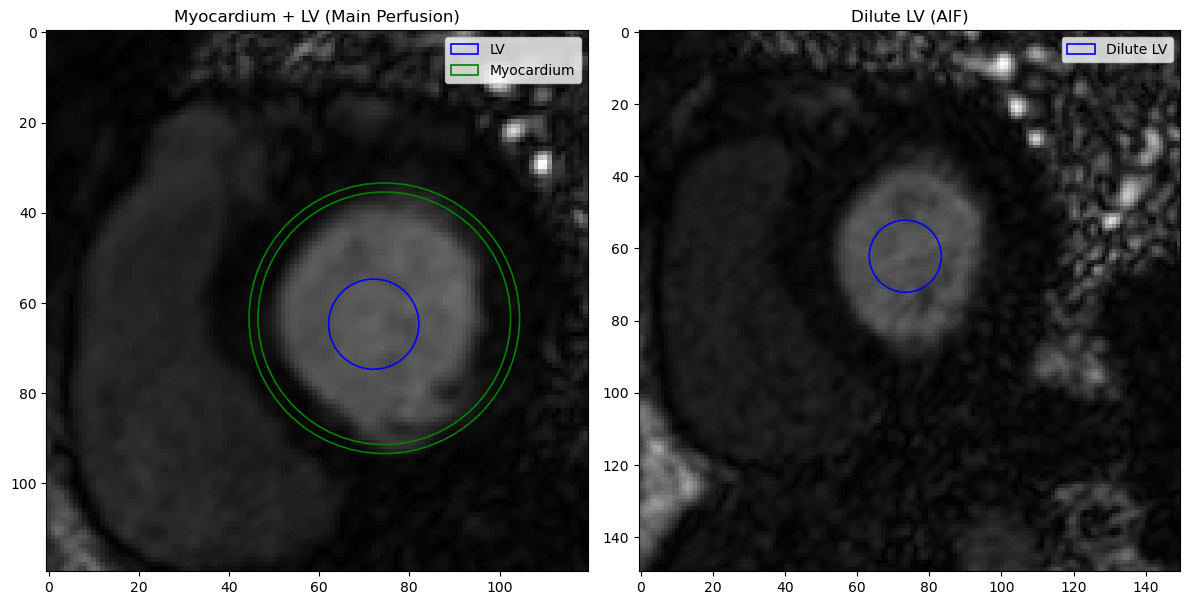

In [14]:
%matplotlib inline

# Myocardium + LV (Main Perfusion)
H, W = images_slice.shape[1:]
Y, X = np.ogrid[:H, :W]

# Myocardium
myo_center = (y_myo_center, x_myo_center)
myo_inner_radius = myo_radius - 1.0
myo_outer_radius = myo_radius + 1.0
myo_mask = ((X - myo_center[1])**2 + (Y - myo_center[0])**2 >= myo_inner_radius**2) & \
           ((X - myo_center[1])**2 + (Y - myo_center[0])**2 <= myo_outer_radius**2)
signal_myo_raw = images_slice[:, myo_mask].mean(axis=1)

# LV (same dataset)
lv_center = (y_lv_center, x_lv_center)
lv_radius = 10        # change as needed
lv_mask = (X - lv_center[1])**2 + (Y - lv_center[0])**2 <= lv_radius**2
signal_lv_raw = images_slice[:, lv_mask].mean(axis=1)

# Dilute LV (Separate AIF Series)
H_dil, W_dil = aif_images_slice.shape[1:]
Y_dil, X_dil = np.ogrid[:H_dil, :W_dil]

lv_dil_center = (y_dil_lv_center, x_dil_lv_center)
lv_dil_radius = 10      # change as needed
lv_dil_mask = (X_dil - lv_dil_center[1])**2 + (Y_dil - lv_dil_center[0])**2 <= lv_dil_radius**2
dilute_signal_lv_raw = aif_images_slice[:, lv_dil_mask].mean(axis=1)

# Display side-by-side
frame_idx = 15
img_main = images_slice[frame_idx]
img_dil = aif_images_slice[frame_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: Myocardium + LV
axes[0].imshow(img_main, cmap="gray")
axes[0].set_title("Myocardium + LV (Main Perfusion)")
axes[0].add_patch(patches.Circle((lv_center[1], lv_center[0]), lv_radius,
                                 edgecolor="blue", facecolor="none", linewidth=1.2, label="LV"))
axes[0].add_patch(patches.Circle((myo_center[1], myo_center[0]), myo_outer_radius,
                                 edgecolor="green", facecolor="none", linewidth=1.2, label="Myocardium"))
axes[0].add_patch(patches.Circle((myo_center[1], myo_center[0]), myo_inner_radius,
                                 edgecolor="green", facecolor="none", linewidth=1.2))
axes[0].legend()

# Right: Dilute LV
axes[1].imshow(img_dil, cmap="gray")
axes[1].set_title("Dilute LV (AIF)")
axes[1].add_patch(patches.Circle((lv_dil_center[1], lv_dil_center[0]), lv_dil_radius,
                                 edgecolor="blue", facecolor="none", linewidth=1.2, label="Dilute LV"))
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# Shift so start lines up for dilute and saturated runs

# Smooth unscaled signals
aif_dilute_smooth = gaussian_filter1d(dilute_signal_lv_raw, sigma=1)
aif_sat_smooth  = gaussian_filter1d(signal_lv_raw, sigma=1)

# Derivatives
deriv_dilute = np.gradient(aif_dilute_smooth)
deriv_sat    = np.gradient(aif_sat_smooth)

# Thresholds (change if needed)
thresh_dilute = 0.2 * np.max(deriv_dilute)
thresh_sat    = 0.2 * np.max(deriv_sat)

possible_starts_dilute = np.where(deriv_dilute > thresh_dilute)[0]
possible_starts_sat    = np.where(deriv_sat > thresh_sat)[0]

start_dilute = possible_starts_dilute[0] - 2 if len(possible_starts_dilute) > 0 else 2
start_saturated = possible_starts_sat[0]    - 2 if len(possible_starts_sat) > 0 else 2

print("Dilute start:", start_dilute)
print("Saturated start:", start_saturated)

# Compute shift
frame_shift = start_saturated - start_dilute
print("Shifting dilute AIF by", frame_shift, "frames")

frame_time_ms = getattr(perfusion_files[0], "FrameTime", 1000)
dt = frame_time_ms / 1000.0

# Convert frame shift to seconds
time = np.arange(len(dilute_signal_lv_raw)) * dt
shift_seconds = frame_shift * dt

shifted_t = time - shift_seconds

dilute_shifted = np.interp(shifted_t, time, dilute_signal_lv_raw, left=0, right=0)

Dilute start: 8
Saturated start: 9
Shifting dilute AIF by 1 frames


In [16]:
# Find first-pass window

start = start_saturated

# Baseline removal (temporary, for windowing and scale factor estimate)
dilute_tmp = dilute_shifted - np.mean(dilute_shifted[:start])
dilute_tmp[:start] = 0

# Peak and end
peak = np.argmax(dilute_tmp)
post_peak = dilute_tmp[peak:]

nonzero_idx = np.where(post_peak > 0)[0]
idx_min = np.argmin(post_peak[nonzero_idx])
end = peak + nonzero_idx[idx_min]

print("Window start:", start)
print("Window end:", end)

Window start: 9
Window end: 30


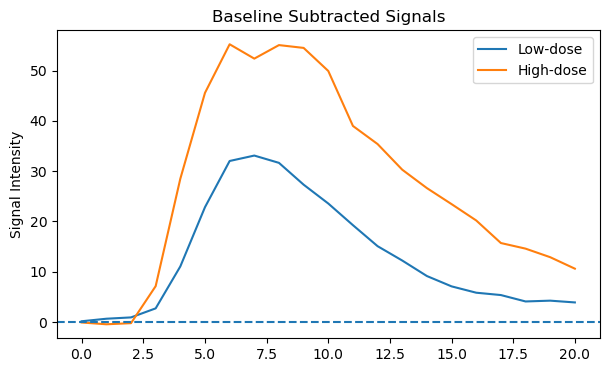

Nonlinear fit parameters:
A = 67.38007164610967
B = 2.7759883050199206e-05
K = 1865.715075694567
Estimated scale factor (A*B*K): 3.489750847494419
Number of points used: 18


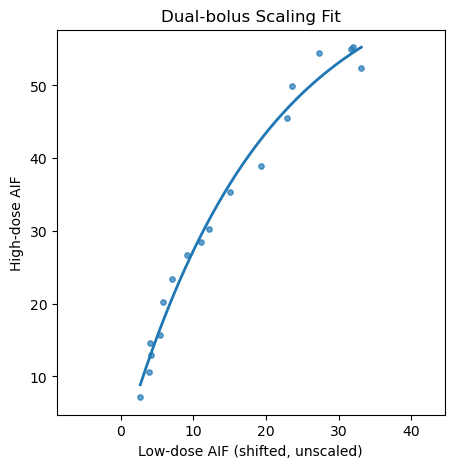

Scale Factor: 3.489750847494419


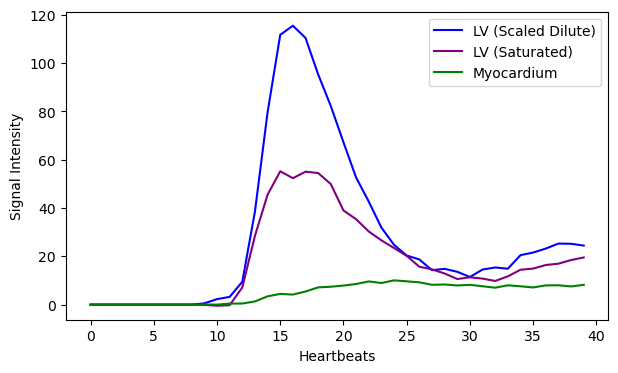

In [17]:
# Fit dual-bolus runs to estimate scale factor or use predetermined scale factor

estimate_scale_factor = True

# If not estimating the scale factor, enter here:
scale_factor = 4.0 

#baseline
signal_myo = signal_myo_raw - np.mean(signal_myo_raw[:start])
signal_lv_tmp  = signal_lv_raw  - np.mean(signal_lv_raw[:start])
signal_myo[:start] = 0
signal_lv_tmp[:start] = 0

# Extract windowed data 
low_win  = dilute_tmp[start:end]
high_win = signal_lv_tmp[start:end]


plt.figure(figsize=(7,4))
plt.plot(low_win, label="Low-dose")
plt.plot(high_win, label="High-dose")
plt.axhline(0, linestyle="--")
plt.title("Baseline Subtracted Signals")
plt.ylabel("Signal Intensity")
plt.legend()
plt.show()

if estimate_scale_factor:
    # Exclude saturated section from fitting
    exclude_saturation = False 

    # Use if excluding saturation; finds peak of dilute AIF and exclude adjacent frames
    peak_dilute = np.argmax(dilute_shifted)
    exclude_n = 2  # edit for amount of excluded points
    exclude_start = peak_dilute - exclude_n
    exclude_end   = peak_dilute + exclude_n + 1

    # Build and apply mask
    indices = np.arange(len(dilute_tmp))
    mask = ((indices >= start) & (indices < end) & (dilute_tmp > 0) & (signal_lv_tmp > 0))

    if exclude_saturation:
        mask = mask & ~((indices >= exclude_start) & (indices < exclude_end))

    low_win  = dilute_tmp[mask]
    high_win = signal_lv_tmp[mask]

    # Estimate least-squares scale factor
    # Nonlinear model: S_high = A(1 - (1 - B * S_low)^K)
    def nonlinear_model(low, A, B, K):
        return A * (1 - (1 - B * low)**K)

    # Initial guesses
    A0 = np.max(high_win)
    B0 = 1.0 / np.max(low_win)
    K0 = 2.0

    popt, pcov = curve_fit(
        nonlinear_model,
        low_win,
        high_win,
        p0=[A0, B0, K0],
        bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),  # keep parameters positive
        maxfev=20000
    )

    A_est, B_est, K_est = popt

    # Effective slope near zero
    scale_factor_est = A_est * K_est * B_est

    print("Nonlinear fit parameters:")
    print("A =", A_est)
    print("B =", B_est)
    print("K =", K_est)
    print("Estimated scale factor (A*B*K):", scale_factor_est)
    print("Number of points used:", len(low_win))

    # Scale
    signal_lv_scaled = dilute_tmp * scale_factor_est

    # Plot scaling relationship
    x_fit = np.linspace(np.min(low_win), np.max(low_win), 200)
    y_fit = nonlinear_model(x_fit, A_est, B_est, K_est)

    plt.figure(figsize=(5,5))
    plt.scatter(low_win, high_win, s=15, alpha=0.7)
    plt.plot(x_fit, y_fit, linewidth=2)
    plt.xlabel("Low-dose AIF (shifted, unscaled)")
    plt.ylabel("High-dose AIF")
    plt.title("Dual-bolus Scaling Fit")
    plt.axis("equal")
    plt.show()
else:
    scale_factor_est = scale_factor
    
signal_lv_scaled = dilute_tmp * scale_factor_est


# Plot to visualize excluded region if applicable
if estimate_scale_factor and exclude_saturation:
    indices = np.arange(len(dilute_shifted))

    # AIF plot
    plt.figure(figsize=(7,4))
    plt.plot(signal_lv_scaled, label="LV (Scaled Dilute)", color="blue")
    plt.plot(signal_lv_tmp, label="LV (Saturated)", color="purple")

    # Fitting window and excluded saturation region
    plt.axvspan(start, end, color="gray", alpha=0.2, label="Fitting window")
    plt.axvspan(exclude_start, exclude_end, color="red", alpha=0.25, label="Excluded region")

    plt.xlabel("Heartbeats")
    plt.ylabel("Signal Intensity")
    plt.title("AIF Scaling Window and Saturation Exclusion")
    plt.legend()
    plt.show()



print("Scale Factor:", scale_factor_est)
# Plot final LV and Myocardium signals
plt.figure(figsize=(7,4))
plt.plot(signal_lv_scaled, label="LV (Scaled Dilute)", color="blue")
plt.plot(signal_lv_tmp, label="LV (Saturated)", color="purple")
plt.plot(signal_myo, label="Myocardium", color="green")
plt.xlabel("Heartbeats")
plt.ylabel("Signal Intensity")
plt.legend()
plt.show()

In [40]:
# Fermi Model
# Explicit NLLS solver using Levenberg–Marquardt algorithm, no additional AIF shift

def run_fermi(signal_lv_scaled, signal_myo, start, end, frame_time_ms, make_plots=True):
    Caif = signal_lv_scaled[start:end]
    Ct = signal_myo[start:end]

    # Time vector
    t = np.arange(len(Caif)) * frame_time_ms / 1000.0
    dt = t[1] - t[0]

    def residuals(params):
        A, mu, k = params
        R = A / (1.0 + np.exp((t - mu) / k))
        Ct_model = np.convolve(Caif, R)[:len(t)] * dt
        return Ct - Ct_model

    p0 = [0.01, 2.0, 2.0]

    res = least_squares(residuals, p0, method='lm', max_nfev=20000)
    A_fit, mu_fit, k_fit = res.x

    R_fit = A_fit / (1.0 + np.exp((t - mu_fit) / k_fit))
    Ct_fit = np.convolve(Caif, R_fit)[:len(t)] * dt

    # MBF (mL/min/g) assuming myocardial density = 1.05 g/mL
    MBF = R_fit[0] * 60 / 1.05
    
    
    r2 = None
    
    if make_plots:
        # Main fit plot
        plt.figure(figsize=(8,5))
        plt.plot(t, Ct, color='green', label='Measured Myocardium')
        plt.plot(t, Ct_fit, color='black', label=f'Fermi Fit')
        plt.plot(t, Caif/np.max(Caif)*np.max(Ct), color='blue', label='AIF')
        plt.plot(t, R_fit/np.max(R_fit)*np.max(Ct), color='red', label='Fermi Function')
        plt.xlabel("Time (s)")
        plt.ylabel("Signal Intensity")
        plt.title("Fermi Deconvolution")
        plt.legend()
        plt.show()

        # Convolution relationship plot
        fig, axes = plt.subplots(1, 3, figsize=(15,4))
        plt.subplots_adjust(wspace=0.4)

        axes[0].plot(t, Caif, color='blue', label='AIF')
        axes[0].set_title('AIF (input)')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Signal')

        axes[1].plot(t, R_fit, color='red', label='Fermi Function')
        axes[1].set_title('TTF')
        axes[1].set_xlabel('Time (s)')
        axes[1].legend()

        axes[2].plot(t, Ct, color='green', label='Measured Myocardium')
        axes[2].plot(t, Ct_fit, color='black', label='Fermi Fit')
        axes[2].set_title('Myocardium')
        axes[2].set_xlabel('Time (s)')
        axes[2].legend()

        fig.text(0.35, 0.55, '⨂', fontsize=24, ha='center', va='center')
        fig.text(0.64, 0.55, '=', fontsize=24, ha='center', va='center')

        plt.show()

        # residuals
        r2 = plot_residuals(Ct, Ct_fit, t, method_name="fermi")   
    
    return {
        "method": "fermi",
        "R": R_fit,
        "Ct_fit": Ct_fit,
        "params": res.x,
        "r2": r2,
        "MBF": MBF,
        "success": res.success
    }

In [41]:
# Fermi Model with Delay
# Explicit NLLS solver using Levenberg–Marquardt algorithm

def run_fermi_delay(signal_lv_scaled, signal_myo, start, end, frame_time_ms, fixed_delay=None, make_plots=True):
    
    Caif = signal_lv_scaled[start:end]
    Ct = signal_myo[start:end]

    t = np.arange(len(Caif)) * frame_time_ms / 1000.0
    dt = t[1] - t[0]

    if fixed_delay is None:

        def residuals(params):
            A, mu, k, delta_t = params
            shifted_t = t - delta_t
            Caif_shifted = np.interp(shifted_t, t, Caif, left=0, right=0)

            R = A / (1.0 + np.exp((t - mu) / k))
            Ct_model = np.convolve(Caif_shifted, R)[:len(t)] * dt
            return Ct - Ct_model

        p0 = [0.01, 2.0, 2.0, 0.0]
        res = least_squares(residuals, p0, method='lm', max_nfev=20000)

        A_fit, mu_fit, k_fit, delta_t_fit = res.x

    #fixed physiological delay
    else:
        def residuals(params):
            A, mu, k = params
            shifted_t = t - fixed_delay
            Caif_shifted = np.interp(shifted_t, t, Caif, left=0, right=0)

            R = A / (1.0 + np.exp((t - mu) / k))
            Ct_model = np.convolve(Caif_shifted, R)[:len(t)] * dt
            return Ct - Ct_model

        p0 = [0.01, 2.0, 2.0]
        res = least_squares(residuals, p0, method='lm', max_nfev=20000)

        A_fit, mu_fit, k_fit = res.x
        delta_t_fit = fixed_delay
    
    
    Caif_shifted = np.interp(t - delta_t_fit, t, Caif, left=0, right=0)
    R_fit = A_fit / (1.0 + np.exp((t - mu_fit) / k_fit))
    Ct_fit = np.convolve(Caif_shifted, R_fit)[:len(t)] * dt

    # MBF (mL/min/g)
    MBF = R_fit[0] * 60 / 1.05

    
    r2 = None
    
    if make_plots:
        #Main fit plot
        plt.figure(figsize=(8,5))
        plt.plot(t, Ct, color='green', label='Measured Myocardium')
        plt.plot(t, Ct_fit, color='black', label=f'Fermi + Delay')
        plt.plot(t,
                 Caif_shifted / np.max(Caif_shifted) * np.max(Ct),
                 color='blue',
                 label='AIF (shifted)')
        plt.plot(t,
                 R_fit / np.max(R_fit) * np.max(Ct),
                 color='red',
                 label='Fermi Function')
        plt.xlabel("Time (s)")
        plt.ylabel("Signal Intensity")
        plt.title("Fermi Deconvolution with Delay (Explicit NLLS)")
        plt.legend()
        plt.show()

        #Convolution relationship
        fig, axes = plt.subplots(1, 3, figsize=(15,4))
        plt.subplots_adjust(wspace=0.4)

        axes[0].plot(t, Caif_shifted, color='blue', label='AIF (shifted)')
        axes[0].set_title('AIF (input)')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Signal')

        axes[1].plot(t, R_fit, color='red', label='Fermi Function')
        axes[1].set_title('TTF')
        axes[1].set_xlabel('Time (s)')
        axes[1].legend()

        axes[2].plot(t, Ct, color='green', label='Measured Myocardium')
        axes[2].plot(t, Ct_fit, color='black', label='Fermi Fit')
        axes[2].set_title('Myocardium')
        axes[2].set_xlabel('Time (s)')
        axes[2].legend()

        fig.text(0.35, 0.55, '⨂', fontsize=24, ha='center', va='center')
        fig.text(0.64, 0.55, '=', fontsize=24, ha='center', va='center')

        plt.show()

        # AIF shift comparison
        plt.figure(figsize=(6,4))
        plt.plot(t, Caif, label='Original AIF', color='gray', alpha=0.6)
        plt.plot(t, Caif_shifted, label=f'Shifted AIF (δt={delta_t_fit:.2f} s)', color='blue')
        plt.xlabel("Time (s)")
        plt.ylabel("Signal")
        plt.legend()
        plt.show()

        # Residuals
        r2 = plot_residuals(Ct, Ct_fit, t, method_name="Fermi + Delay")
    
    return {
        "method": "fermi_delay",
        "R": R_fit,
        "Ct_fit": Ct_fit,
        "params": res.x,
        "delta_t": delta_t_fit,
        "r2": r2,
        "MBF": MBF,
        "success": res.success
    }

In [52]:
# Model-Free Method

# quadratic programming solver
def model_free_qp(Caif, Ct, dt, lam=1e-3, verbose=False):
    n = len(Ct)

    # Toeplitz convolution matrix
    H = np.zeros((n, n))
    for i in range(n):
        H[i, :i+1] = Caif[i::-1] * dt

    P = H.T @ H + lam * np.eye(n)
    q = -H.T @ Ct

    # Constraints:
        # Non-negativity constraint: RF(t) >= 0
        # Monotonic decreasing constraint: RF(t+1) <= RF(t)
    G1 = -np.eye(n) 
    h1 = np.zeros(n)

    G2 = np.zeros((n-1, n))
    for i in range(n-1):
        G2[i, i]   = -1.0
        G2[i, i+1] =  1.0
    h2 = np.zeros(n-1)

    G = np.vstack([G1, G2])
    h_ub = np.hstack([h1, h2])

    #OSQP solver
    P_sparse = sparse.csc_matrix((P + P.T) / 2.0)
    A_sparse = sparse.csc_matrix(G)

    prob = osqp.OSQP()
    prob.setup(P=P_sparse, q=q, A=A_sparse, l=-np.inf*np.ones(G.shape[0]), u=h_ub, verbose=verbose)
    res = prob.solve()

    if res.info.status_val not in (1, 2):
        raise RuntimeError(f"OSQP failed: {res.info.status}")

    RF = np.maximum(res.x, 0.0)
    for i in range(1, len(RF)): # enforce monotonicity
        RF[i] = min(RF[i], RF[i-1])

    return RF, res


def run_model_free(signal_lv_scaled, signal_myo, start, end, frame_time_ms, lam=1e-3, make_plots=True):

    dt = frame_time_ms / 1000.0

    Caif = signal_lv_scaled[start:end].astype(float)
    Ct   = signal_myo[start:end].astype(float)

    RF, res = model_free_qp(Caif, Ct, dt, lam=lam, verbose=False)

    #reconvolution check
    Ct_model = np.convolve(Caif, RF)[:len(Caif)] * dt
    
    # MBF (mL/min/g)
    MBF = RF[0] * 60 / 1.05
    V   = np.sum(RF) * dt
    MTT = V / RF[0] if RF[0] > 0 else np.nan

    
    r2 = None
    
    if make_plots:
        t = np.arange(len(RF)) * dt

        plt.figure()
        plt.plot(t, RF, '-o')
        plt.xlabel("Time (s)")
        plt.ylabel("RF(t)")
        plt.title("Model-Free RF(t)")
        plt.show()
        
        
        #reconvolution fit
        fig, axes = plt.subplots(1, 3, figsize=(15,4))
        plt.subplots_adjust(wspace=0.4)
        # AIF
        axes[0].plot(t, Caif, color='blue', label='AIF')
        axes[0].set_title('AIF (input)')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Signal')
        axes[0].legend()
        # TTF
        axes[1].plot(t, RF, color='red', label='RF(t)')
        axes[1].set_title('TTF')
        axes[1].set_xlabel('Time (s)')
        axes[1].legend()
        # Myocardium
        axes[2].plot(t, Ct, color='green', label='Measured Myocardium')
        axes[2].plot(t, Ct_model, color='black', label='Reconvolution Fit')
        axes[2].set_title('Myocardium')
        axes[2].set_xlabel('Time (s)')
        axes[2].legend()
        
        fig.text(0.35, 0.55, '⨂', fontsize=24, ha='center', va='center')
        fig.text(0.64, 0.55, '=', fontsize=24, ha='center', va='center')
        plt.show()
        
        #residuals
        r2 = plot_residuals(Ct, Ct_model, t, method_name="model_free")

    return {
        "method": "model_free",
        "R": RF,
        "r2": r2,
        "MBF": MBF,
        "MTT": MTT,
        "qp_result": res
    }

In [53]:
# Check residuals for best fit

def plot_residuals(Ct, Ct_fit, t, method_name=""):
    ss_res = np.sum((Ct - Ct_fit) ** 2)
    ss_tot = np.sum((Ct - np.mean(Ct)) ** 2)
    r2 = 1 - ss_res / ss_tot

    residuals = Ct - Ct_fit

    plt.figure()
    plt.plot(t[:len(residuals)], residuals, 'o-')
    plt.hlines(0, t[0], t[len(residuals)-1], colors='k', linestyles='dashed')
    plt.xlabel("Time (s)")
    plt.ylabel("Residual (Measured − Fit)")
    plt.title(f"Fit Residuals ({method_name})")
    plt.show()
    
    print(f"{method_name} R² = {r2:.3f}")

    return r2

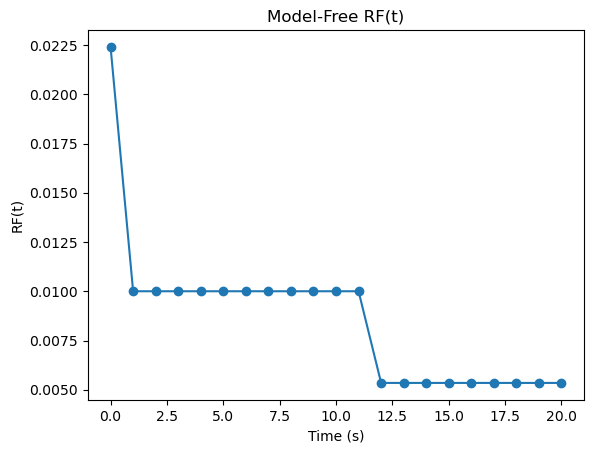

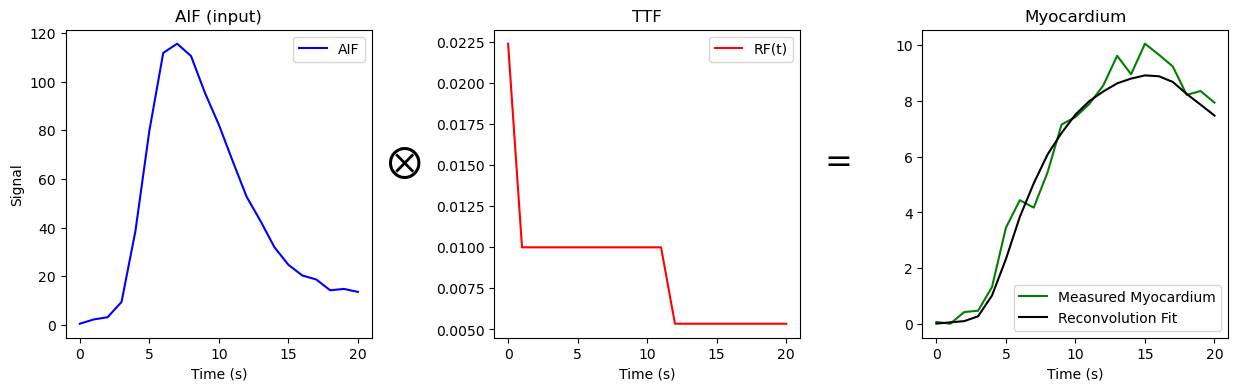

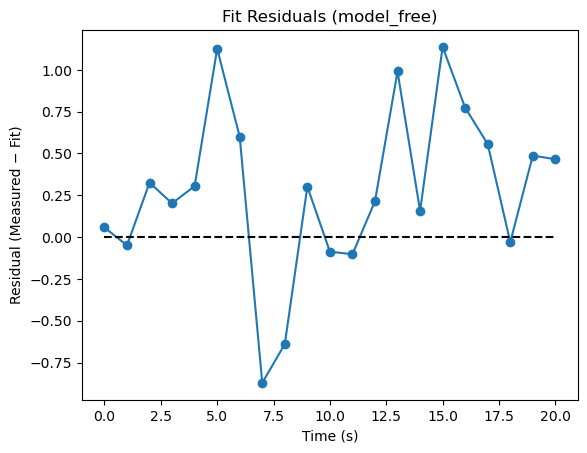

model_free R² = 0.973
Method: model_free
MBF: 1.2802213992840885


In [54]:
METHOD = "model_free"  # "fermi", "fermi_delay", "model_free"
FIXED_DELAY = None # None, or add a predetermined delay value if applicable, for fermi_delay

frame_time_ms = getattr(perfusion_files[0], "FrameTime", 1000)

if METHOD == "fermi":
    results = run_fermi(signal_lv_scaled, signal_myo, start, end, frame_time_ms)

elif METHOD == "fermi_delay":
    results = run_fermi_delay(signal_lv_scaled, signal_myo, start, end, frame_time_ms, fixed_delay=FIXED_DELAY)

elif METHOD == "model_free":
    results = run_model_free(signal_lv_scaled, signal_myo, start, end, frame_time_ms)

else:
    raise ValueError("Unknown method")

print("Method:", results["method"])
print("MBF:", results["MBF"])